In [2]:
%pip install seaborn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
RANDOM_STATE = 42

In [4]:
# Load dataset: target 0 = malignant, 1 = benign
cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target
df = X.copy()
df['target'] = y
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})
df.to_csv('breast_cancer_dataset.csv', index=False)

print('Dataset shape:', df.shape)
print('CSV saved as: breast_cancer_dataset.csv')
display(df.head())
display(df['diagnosis'].value_counts())

Dataset shape: (569, 32)
CSV saved as: breast_cancer_dataset.csv


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


diagnosis
benign       357
malignant    212
Name: count, dtype: int64

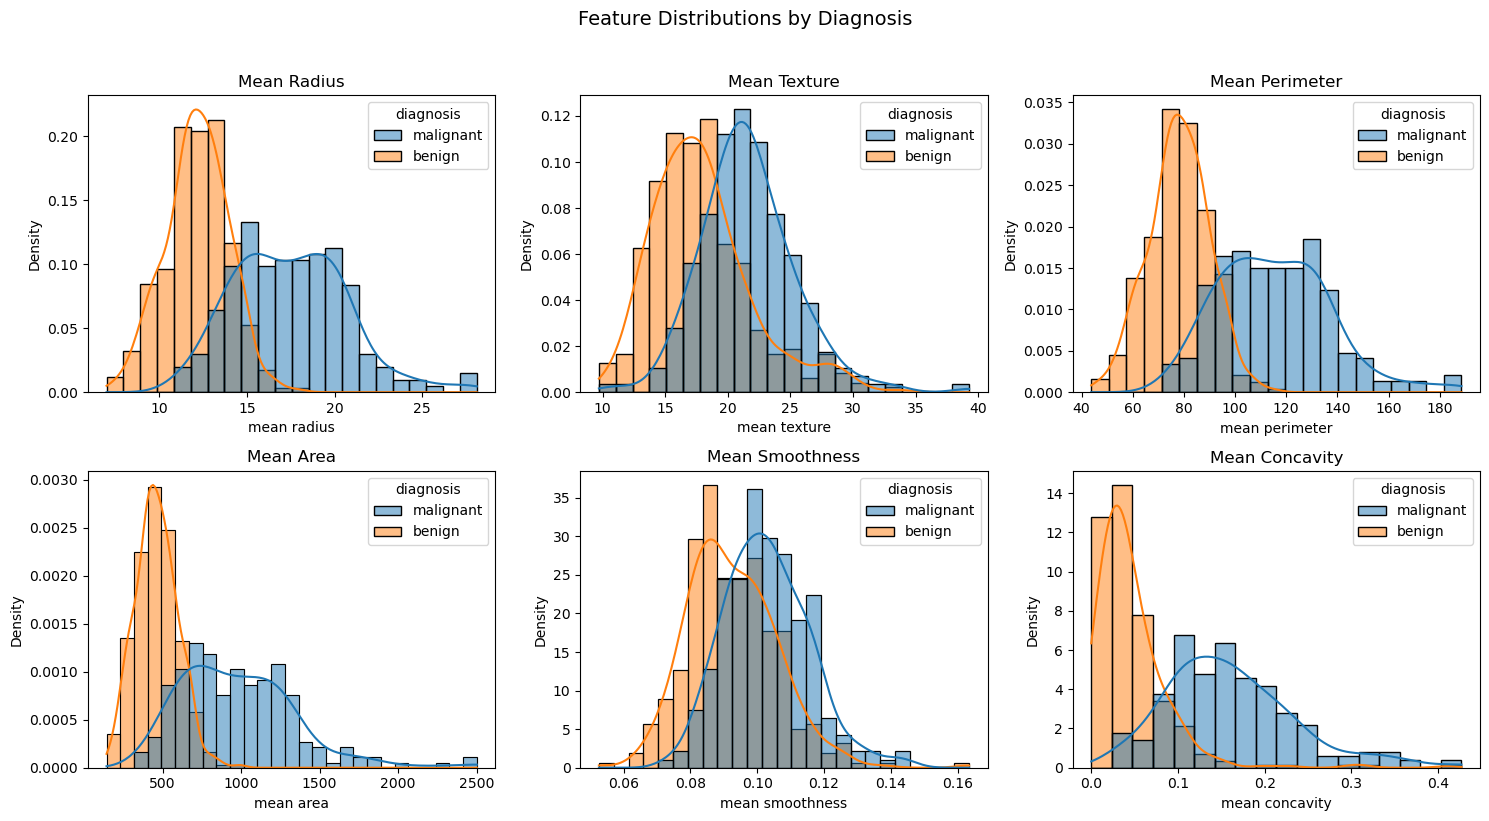

In [22]:
# Plot 2: distributions of important input features
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean concavity']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for feature, ax in zip(features_to_plot, axes.flat):
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True, stat='density', common_norm=False, ax=ax)
    ax.set_title(feature.title())
plt.suptitle('Feature Distributions by Diagnosis', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

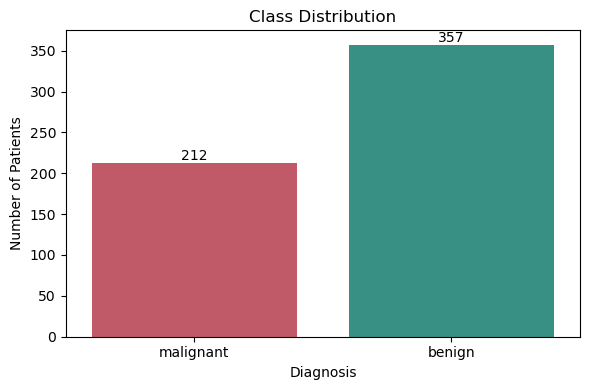

In [24]:
# Plot 1: number of benign and malignant records
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='diagnosis', hue='diagnosis', legend=False, palette=['#d1495b', '#2a9d8f'])
plt.title('Class Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

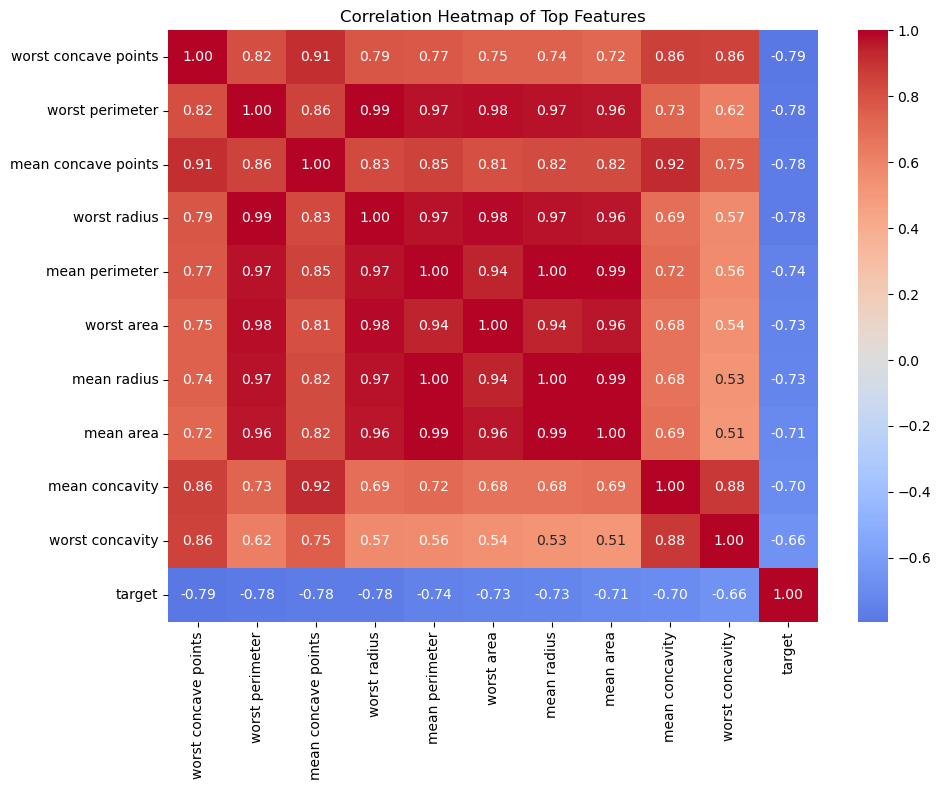

In [25]:
# Plot 3: correlation between the ten most target-related features
correlations = df.drop(columns='diagnosis').corr()['target'].abs().sort_values(ascending=False)
top_features = correlations.index[1:11].tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features + ['target']].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Top Features')
plt.tight_layout()
plt.show()

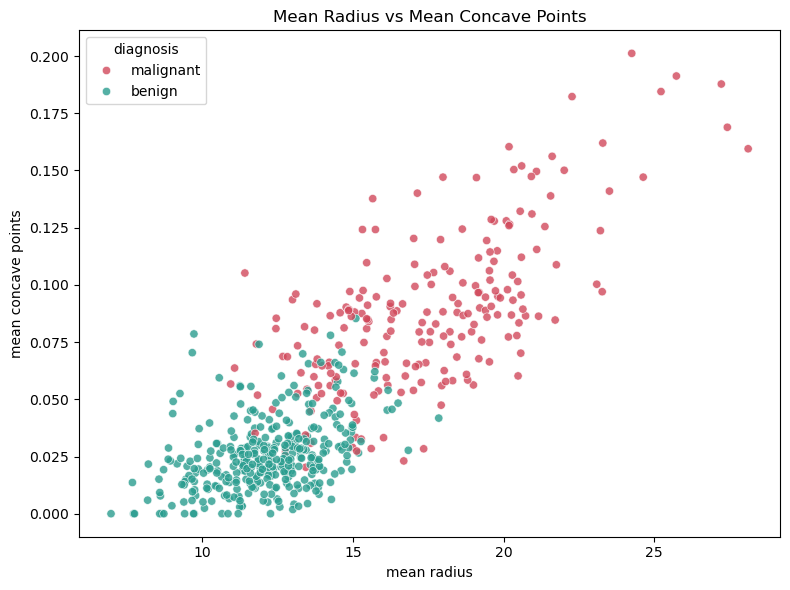

In [26]:
# Plot 4: scatter plot showing how two features separate the classes
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='mean radius', y='mean concave points', hue='diagnosis', alpha=0.8, palette=['#d1495b', '#2a9d8f'])
plt.title('Mean Radius vs Mean Concave Points')
plt.tight_layout()
plt.show()

In [5]:
# Stratification keeps the class ratio similar in training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 455
Testing rows: 114


In [6]:
# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

In [11]:
%pip install lightgbm

In [12]:
# LightGBM model
lgbm_model = LGBMClassifier(
    n_estimators=300, num_leaves=15, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_predictions = lgbm_model.predict(X_test)
lgbm_probabilities = lgbm_model.predict_proba(X_test)[:, 1]

In [13]:
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(
    n_estimators=300,
    num_leaves=15,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_predictions = lgbm_model.predict(X_test)
lgbm_probabilities = lgbm_model.predict_proba(X_test)[:, 1]

In [17]:
# Compare accuracy and ROC-AUC
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Accuracy': [accuracy_score(y_test, xgb_predictions), accuracy_score(y_test, lgbm_predictions)],
    'ROC-AUC': [roc_auc_score(y_test, xgb_probabilities), roc_auc_score(y_test, lgbm_probabilities)]
}).sort_values('Accuracy', ascending=False)
print(results.to_string(
    index=False,
    formatters={
        'Accuracy': '{:.2%}'.format,
        'ROC-AUC': '{:.3f}'.format
    }
))
print('\nXGBoost classification report:\n')
print(classification_report(y_test, xgb_predictions, target_names=cancer.target_names))
print('LightGBM classification report:\n')
print(classification_report(y_test, lgbm_predictions, target_names=cancer.target_names))

   Model Accuracy ROC-AUC
LightGBM   96.49%   0.989
 XGBoost   95.61%   0.994

XGBoost classification report:

              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

LightGBM classification report:

              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



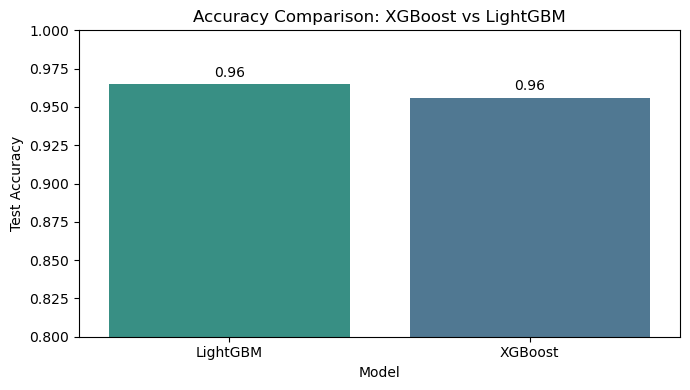

In [18]:
# Plot 1: model accuracy comparison
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=results, x='Model', y='Accuracy', hue='Model', legend=False, palette=['#2a9d8f', '#457b9d'])
plt.ylim(0.80, 1.00)
plt.title('Accuracy Comparison: XGBoost vs LightGBM')
plt.ylabel('Test Accuracy')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

,Feature,XGBoost importance,LightGBM importance,Average importance
21,worst texture,0.017232,341,170.508616
27,worst concave points,0.077990,339,169.538995
22,worst perimeter,0.243681,260,130.121841
7,mean concave points,0.133494,232,116.066747
20,worst radius,0.190929,212,106.095465
24,worst smoothness,0.014739,201,100.507370
1,mean texture,0.014664,193,96.507332
23,worst area,0.057189,191,95.528595
28,worst symmetry,0.005058,184,92.002529
13,area error,0.011520,178,89.005760


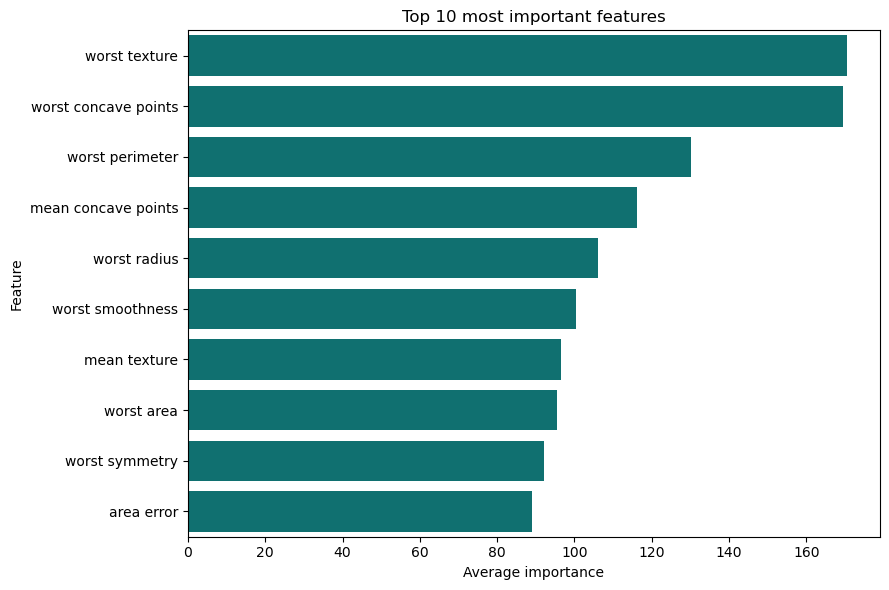

In [19]:
# Feature importance: use this in your project report
importance = pd.DataFrame({
    'Feature': X.columns,
    'XGBoost importance': xgb_model.feature_importances_,
    'LightGBM importance': lgbm_model.feature_importances_
})
importance['Average importance'] = importance[['XGBoost importance', 'LightGBM importance']].mean(axis=1)
importance = importance.sort_values('Average importance', ascending=False)
display(importance.head(10))

plt.figure(figsize=(9, 6))
sns.barplot(data=importance.head(10), x='Average importance', y='Feature', color='teal')
plt.title('Top 10 most important features')
plt.tight_layout()
plt.show()

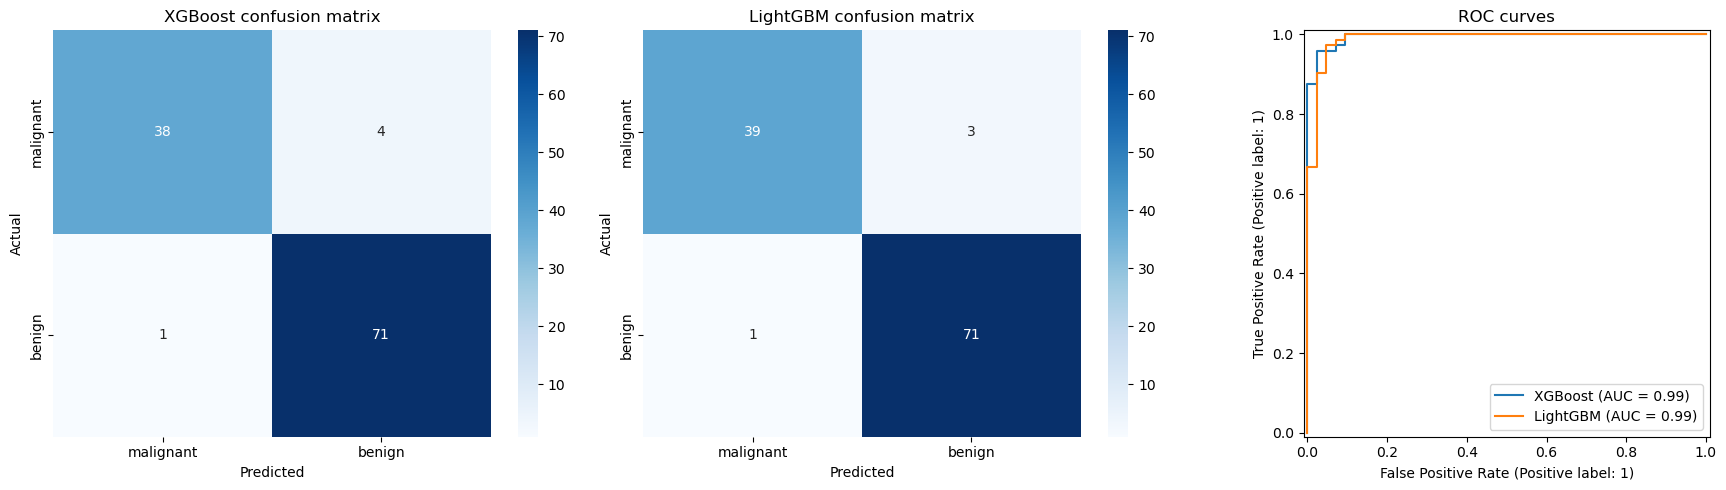

In [20]:
# Confusion matrices and ROC curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name, predictions in zip(axes[:2], ['XGBoost', 'LightGBM'], [xgb_predictions, lgbm_predictions]):
    sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=cancer.target_names, yticklabels=cancer.target_names)
    ax.set_title(f'{name} confusion matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
RocCurveDisplay.from_predictions(y_test, xgb_probabilities, name='XGBoost', ax=axes[2])
RocCurveDisplay.from_predictions(y_test, lgbm_probabilities, name='LightGBM', ax=axes[2])
axes[2].set_title('ROC curves')
plt.tight_layout()
plt.show()

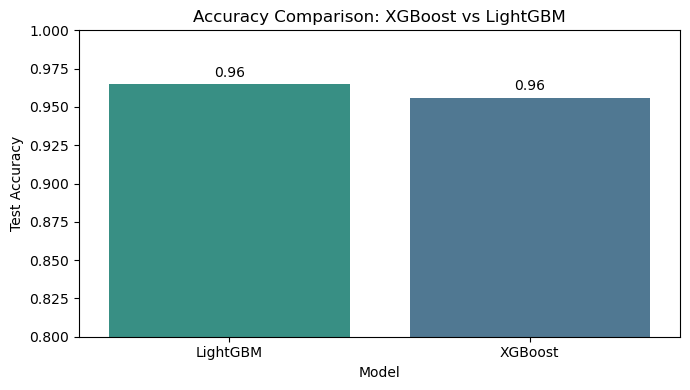

In [21]:
# Plot 1: model accuracy comparison
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=results, x='Model', y='Accuracy', hue='Model', legend=False, palette=['#2a9d8f', '#457b9d'])
plt.ylim(0.80, 1.00)
plt.title('Accuracy Comparison: XGBoost vs LightGBM')
plt.ylabel('Test Accuracy')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Accuracy': [accuracy_score(y_test, xgb_predictions), accuracy_score(y_test, lgbm_predictions)],
    'ROC-AUC': [roc_auc_score(y_test, xgb_probabilities), roc_auc_score(y_test, lgbm_probabilities)]
}).sort_values('Accuracy', ascending=False)
print(results.to_string(
    index=False,
    formatters={
        'Accuracy': '{:.2%}'.format,
        'ROC-AUC': '{:.3f}'.format
    }
))
print('\nXGBoost classification report:\n')
print(classification_report(y_test, xgb_predictions, target_names=cancer.target_names))
print('LightGBM classification report:\n')
print(classification_report(y_test, lgbm_predictions, target_names=cancer.target_names))

   Model Accuracy ROC-AUC
LightGBM   96.49%   0.989
 XGBoost   95.61%   0.994

XGBoost classification report:

              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

LightGBM classification report:

              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

